# Space-Time Accessibility vs. Leisure Activity
Data filtering, visualization, and output for R SEM model.

**Outputs:**
- `dbs/data_p/commuter_model_features_r.csv` - Features for R SEM
- `figures/hill_q1.png`, `figures/total_travel_time.png` - Main figures

In [1]:
%cd D:\netmob25

D:\netmob25


In [2]:
import os
os.environ['USE_PYGEOS'] = '0'
import pandas as pd
import geopandas as gpd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import h3.api.numpy_int as h3
from shapely.geometry import Polygon, Point

In [3]:
# Helper functions
def weighted_median(data, weights):
    data, weights = np.array(data), np.array(weights)
    sorter = np.argsort(data)
    data, weights = data[sorter], weights[sorter]
    cumsum = np.cumsum(weights) / np.sum(weights)
    return data[np.searchsorted(cumsum, 0.5)]

def bootstrap_median(data, weights=None, n_bootstrap=1000, random_state=None):
    rng = np.random.default_rng(random_state)
    data = np.array(data)
    if weights is None:
        weights = np.ones_like(data, dtype=float)
    else:
        weights = np.array(weights, dtype=float)
    median_estimate = weighted_median(data, weights)
    medians = []
    probs = weights / weights.sum()
    for _ in range(n_bootstrap):
        sample_idx = rng.choice(len(data), size=len(data), replace=True, p=probs)
        medians.append(weighted_median(data[sample_idx], weights[sample_idx]))
    return median_estimate, np.std(medians, ddof=1)

In [4]:
# Matplotlib setup
import matplotlib as mpl
mpl.rc('font', size=9)
mpl.rcParams['legend.fontsize'] = 'small'
mpl.rcParams['xtick.labelsize'] = 'small'
mpl.rcParams['ytick.labelsize'] = 'small'
mpl.rcParams['lines.linewidth'] = 1
mpl.rcParams['axes.linewidth'] = 1
mpl.rcParams['xtick.top'] = False
mpl.rcParams['ytick.right'] = False
mpl.rcParams['mathtext.default'] = 'regular'

## 1. Load Data

In [5]:
# Load source data
df_p = pd.read_csv('dbs/data_p/commuter_attributes.csv', low_memory=False)
df_r = pd.read_csv('dbs/data_p/commuter_mobi_efficiency_daily.csv')

# Load weekday leisure metrics (from notebook 2b)
df_leisure = pd.read_csv('dbs/data_p/commuter_leisure_metrics_weekday.csv')

# Load NEW sensitivity STA results (from notebook 7b)
df_sta_sens = pd.read_csv('results/sensitivity/sta_sensitivity_full.csv')

print(f"Attributes: {len(df_p)} rows, {df_p['ID'].nunique()} individuals")
print(f"Mobility: {len(df_r)} rows")
print(f"Leisure metrics: {len(df_leisure)} individuals")
print(f"\nSTA sensitivity results: {len(df_sta_sens)} rows")
print(f"  Parameter combinations:")
print(df_sta_sens.groupby(['mode', 'hour', 'budget']).size())

Attributes: 38113 rows, 2451 individuals
Mobility: 14169 rows
Leisure metrics: 2444 individuals

STA sensitivity results: 12914 rows
  Parameter combinations:
mode  hour  budget
car   17    60         914
            75         914
            90         914
            120        914
pt    16    90        1543
      17    60        1543
            75        1543
            90        1543
            120       1543
      18    90        1543
dtype: int64


## 2. Prepare Individual-Level Features

In [6]:
# Recode transport mode in STA results (lowercase to proper case)
df_sta_sens['mode'] = df_sta_sens['mode'].map({'car': 'Car', 'pt': 'Public transit'})

# Create main_mode_r on attributes
df_p['main_mode_r'] = df_p['main_mode'].apply(
    lambda x: 'Car' if x in ['Private car (driver)', 'Private car (passenger)'] 
    else 'Public transit' if x == 'Public transit' 
    else 'Active/Micro' if x in ['Active', 'Micro'] 
    else 'Other'
)

print(df_p.drop_duplicates(subset=['ID'])['main_mode_r'].value_counts())

main_mode_r
Active/Micro      974
Car               914
Public transit    560
Other               3
Name: count, dtype: int64


In [7]:
# Aggregate mobility metrics to individual level (weighted by day)
df_r2plot = df_r.groupby('ID').agg({
    'entropy_mm': 'first',
    'activity_nh_ratio': lambda x: (x * df_r.loc[x.index, 'weight_day']).sum() / df_r.loc[x.index, 'weight_day'].sum(),
    'activity_time_third': lambda x: (x * df_r.loc[x.index, 'weight_day']).sum() / df_r.loc[x.index, 'weight_day'].sum(),
    'total_travel_time': lambda x: (x * df_r.loc[x.index, 'weight_day']).sum() / df_r.loc[x.index, 'weight_day'].sum(),
    'xs_total_hws': lambda x: (x * df_r.loc[x.index, 'weight_day']).sum() / df_r.loc[x.index, 'weight_day'].sum(),
    'trip_chaining_presence': lambda x: 1 if sum(x) > 0 else 0
}).reset_index().fillna(0)

print(f"Aggregated to {len(df_r2plot)} individuals")

Aggregated to 2456 individuals


In [8]:
# Merge weekday leisure metrics (hill_q1, mean_leisure_duration)
df_r2plot = df_r2plot.merge(
    df_leisure[['ID', 'hill_q1', 'mean_leisure_duration']],
    on='ID', how='left'
)
print(f"With leisure metrics: {df_r2plot['hill_q1'].notna().sum()} with hill_q1, {df_r2plot['mean_leisure_duration'].notna().sum()} with duration")

With leisure metrics: 1454 with hill_q1, 1429 with duration


In [9]:
# Merge individual attributes
attr_cols = ['ID', 'Gender', 'Age', 'Education', 'Household_type', 'weight_ind', 'main_mode_r']
df_r2plot = df_r2plot.merge(
    df_p.drop_duplicates(subset=['ID'])[attr_cols],
    on='ID', how='left'
)
print(f"After attribute merge: {len(df_r2plot)} rows")

After attribute merge: 2456 rows


In [10]:
# Merge home-based accessibility (30 min, Social & Leisure)
df_r2plot = df_r2plot.merge(
    df_p.loc[(df_p['time_threshold'] == '30 min') & (df_p['amenity'] == 'Social & Leisure'),
             ['ID', 'access_h', 'mode']],
    on='ID', how='left'
)
print(f"After home accessibility merge: {len(df_r2plot)} rows")

After home accessibility merge: 4882 rows


## 3. Filter to Analysis Sample

In [11]:
# Match mode: Car users -> Car accessibility, others -> PT accessibility
car_ids = df_r2plot.loc[df_r2plot['main_mode_r'] == 'Car', 'ID'].unique()

df_filtered = df_r2plot[
    ((df_r2plot['ID'].isin(car_ids)) & (df_r2plot['mode'] == 'Car')) |
    ((~df_r2plot['ID'].isin(car_ids)) & (df_r2plot['mode'] == 'Public transit'))
].copy()

# Exclude 'Other' mode users
df_filtered = df_filtered[df_filtered['main_mode_r'] != 'Other'].copy()

print(f"Filtered sample: {len(df_filtered)} individuals")
print(df_filtered['mode'].value_counts())

Filtered sample: 2444 individuals
mode
Public transit    1530
Car                914
Name: count, dtype: int64


In [12]:
# Pivot STA sensitivity results: create columns for each budget level
# Filter to hour=17 (baseline hour for budget sensitivity)
df_sta_h17 = df_sta_sens[df_sta_sens['hour'] == 17].copy()

# Pivot to wide format: one column per budget
df_sta_wide = df_sta_h17.pivot_table(
    index=['ID', 'mode'], 
    columns='budget', 
    values='ak',
    aggfunc='first'
).reset_index()

# Rename columns to ak_60, ak_75, etc.
df_sta_wide.columns = ['ID', 'mode'] + [f'ak_{int(b)}' for b in df_sta_wide.columns[2:]]

# Merge with filtered data
df_filtered = df_filtered.merge(df_sta_wide, on=['ID', 'mode'], how='left')

# Fill missing STA with 0
for col in [c for c in df_filtered.columns if c.startswith('ak_')]:
    df_filtered[col] = df_filtered[col].fillna(0)

# Create transformations for each budget level
budgets = [60, 75, 90, 120]
for b in budgets:
    col = f'ak_{b}'
    df_filtered[f'{col}_ihs'] = np.arcsinh(df_filtered[col])
    df_filtered[f'{col}_log1p'] = np.log1p(df_filtered[col])

# Create baseline aliases (budget=90)
df_filtered['ak'] = df_filtered['ak_90']
df_filtered['ak_ihs'] = df_filtered['ak_90_ihs']
df_filtered['ak_log1p'] = df_filtered['ak_90_log1p']
df_filtered['ak_cat'] = df_filtered['ak'].apply(lambda x: 'Zero' if x == 0 else 'Non-zero')

print(f"STA columns added: {[c for c in df_filtered.columns if 'ak_' in c]}")
print(f"\nSTA distribution (baseline budget=90):")
print(df_filtered['ak_cat'].value_counts())

STA columns added: ['ak_60', 'ak_75', 'ak_90', 'ak_120', 'ak_60_ihs', 'ak_60_log1p', 'ak_75_ihs', 'ak_75_log1p', 'ak_90_ihs', 'ak_90_log1p', 'ak_120_ihs', 'ak_120_log1p', 'ak_ihs', 'ak_log1p', 'ak_cat']

STA distribution (baseline budget=90):
ak_cat
Zero        1524
Non-zero     920
Name: count, dtype: int64


In [13]:
# Add additional attributes
df_filtered = df_filtered.merge(
    df_p[['ID', 'codgeo', 'pt_sub']].drop_duplicates(subset=['ID']),
    on='ID', how='left'
)

# Create active mode indicator
df_filtered['active_mode'] = (df_filtered['main_mode_r'] == 'Active/Micro').astype(int)

print(f"Columns: {list(df_filtered.columns)}")

Columns: ['ID', 'entropy_mm', 'activity_nh_ratio', 'activity_time_third', 'total_travel_time', 'xs_total_hws', 'trip_chaining_presence', 'hill_q1', 'mean_leisure_duration', 'Gender', 'Age', 'Education', 'Household_type', 'weight_ind', 'main_mode_r', 'access_h', 'mode', 'ak_60', 'ak_75', 'ak_90', 'ak_120', 'ak_60_ihs', 'ak_60_log1p', 'ak_75_ihs', 'ak_75_log1p', 'ak_90_ihs', 'ak_90_log1p', 'ak_120_ihs', 'ak_120_log1p', 'ak', 'ak_ihs', 'ak_log1p', 'ak_cat', 'codgeo', 'pt_sub', 'active_mode']


## 4. Visualization Functions

In [43]:
def assign_quantile_bins(data, access_col='access_h', num_grp=None):
    data = data.copy()
    data['grp_cell'] = pd.qcut(data[access_col], q=num_grp, labels=range(1, num_grp + 1))
    data['grp_cell'] = data['grp_cell'].astype(float)
    return data

def access_vs_y(df_input, num_grp=None, access_col='access_h'):
    df = pd.concat([
        assign_quantile_bins(df_input[(df_input[access_col] > 0) & (df_input['mode'] == 'Car')], access_col=access_col, num_grp=num_grp),
        assign_quantile_bins(df_input[(df_input[access_col] > 0) & (df_input['mode'] == 'Public transit')], access_col=access_col, num_grp=num_grp)
    ])
    
    def grp_stats(data):
        md_e, md_err_e = bootstrap_median(data['hill_q1'].dropna(), weights=data.loc[data['hill_q1'].notna(), 'weight_ind'], n_bootstrap=1000)
        md_tt, md_err_tt = bootstrap_median(data['total_travel_time'], weights=data['weight_ind'], n_bootstrap=1000)
        md_mad, md_err_mad = bootstrap_median(data['mean_leisure_duration'], weights=data['weight_ind'], n_bootstrap=1000)
        return pd.Series({
            'r': data[access_col].median(),
            'hill_q1_50': md_e, 'hill_q1_err': md_err_e,
            'total_travel_time_50': md_tt, 'total_travel_time_err': md_err_tt,
            'mean_leisure_duration_50': md_mad, 'mean_leisure_duration_err': md_err_mad
        })
    
    return df.groupby(['grp_cell', 'mode'], observed=True).apply(grp_stats, include_groups=False).reset_index()

In [63]:
def access_impact_plot(df_b, y='diversity', ylb=None):
    fig, axes = plt.subplots(1, 2, figsize=(4, 2), dpi=300, sharey=True)

    def plot_with_fit(ax, df_sub, title, color):
        x = df_sub['r'].to_numpy(dtype=float)
        y50 = df_sub[f'{y}_50'].to_numpy(dtype=float)
        yerr = df_sub[f'{y}_err'].to_numpy(dtype=float)

        ax.errorbar(x, y50, yerr=[yerr, yerr], fmt='o', capsize=2, color=color, markersize=4)

        mask = np.isfinite(x) & (x > 0) & np.isfinite(y50)
        if mask.sum() >= 2:
            x_fit, y_fit = x[mask], y50[mask]
            m, b = np.polyfit(np.log10(x_fit), y_fit, deg=1)
            xs = np.geomspace(x_fit.min(), x_fit.max(), 200)
            ax.plot(xs, m * np.log10(xs) + b, color=color, lw=0.7, alpha=0.7)

        # ax.set_xscale('log')
        ax.set_xlabel('$A_i^*$')
        ax.set_title(title, fontsize=10, loc='left')
        sns.despine(ax=ax)

    plot_with_fit(axes[0], df_b[df_b['mode'] == 'Car'], 'Car', '#0fbcf9')
    plot_with_fit(axes[1], df_b[df_b['mode'] == 'Public transit'], 'Public transit', '#05c46b')
    axes[0].set_ylabel(ylb)
    plt.tight_layout()
    return fig, axes

## 5. Generate Figures

In [39]:
df_filtered.fillna(0, inplace=True)

In [59]:
# Compute binned statistics
df_ak_g = access_vs_y(df_filtered, num_grp=11, access_col='ak_ihs')
df_ak_g['a_type'] = 'Space-time accessibility to leisure'
df_ak_g.head()

,grp_cell,mode,r,hill_q1_50,hill_q1_err,total_travel_time_50,total_travel_time_err,mean_leisure_duration_50,mean_leisure_duration_err,a_type
0,1.0,Car,5.480656,1.0,0.031623,79.799999,2.588876,17.000000,39.007148,Space-time accessibility to leisure
1,1.0,Public transit,3.045663,1.0,0.000000,73.499941,6.856221,10.000000,36.791160,Space-time accessibility to leisure
2,2.0,Car,6.873165,0.0,0.031623,75.470482,7.586230,0.000000,0.632456,Space-time accessibility to leisure
3,2.0,Public transit,4.465974,0.0,0.000000,82.388069,4.724332,0.000000,0.000000,Space-time accessibility to leisure
4,3.0,Car,7.551176,1.0,0.474949,80.097062,3.916424,25.027778,22.470350,Space-time accessibility to leisure


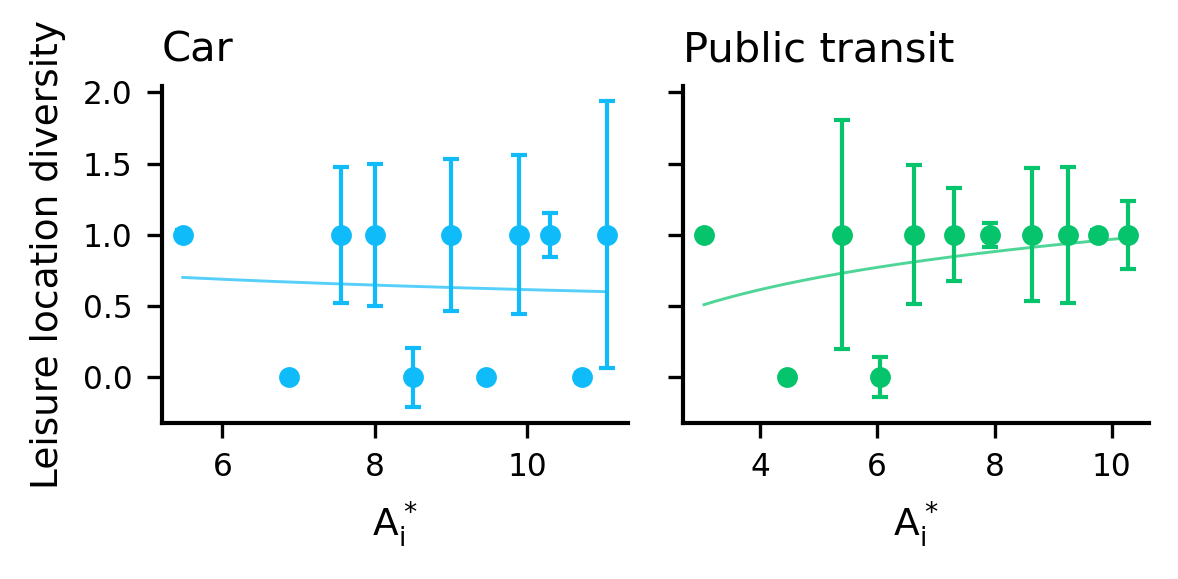

In [64]:
# Figure: STA vs hill_q1
fig, _ = access_impact_plot(df_ak_g, y='hill_q1', ylb='Leisure location diversity')
fig.savefig('figures/hill_q1.png', dpi=300, bbox_inches='tight')
plt.show()

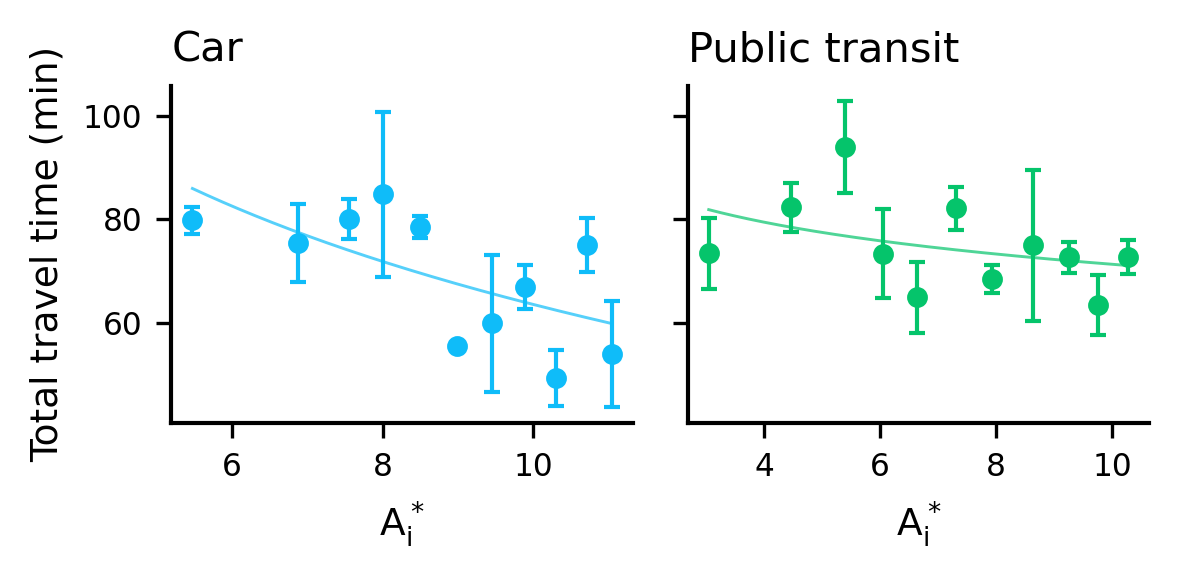

In [65]:
# Figure: STA vs total_travel_time
fig, _ = access_impact_plot(df_ak_g, y='total_travel_time', ylb='Total travel time (min)')
fig.savefig('figures/total_travel_time.png', dpi=300, bbox_inches='tight')
plt.show()

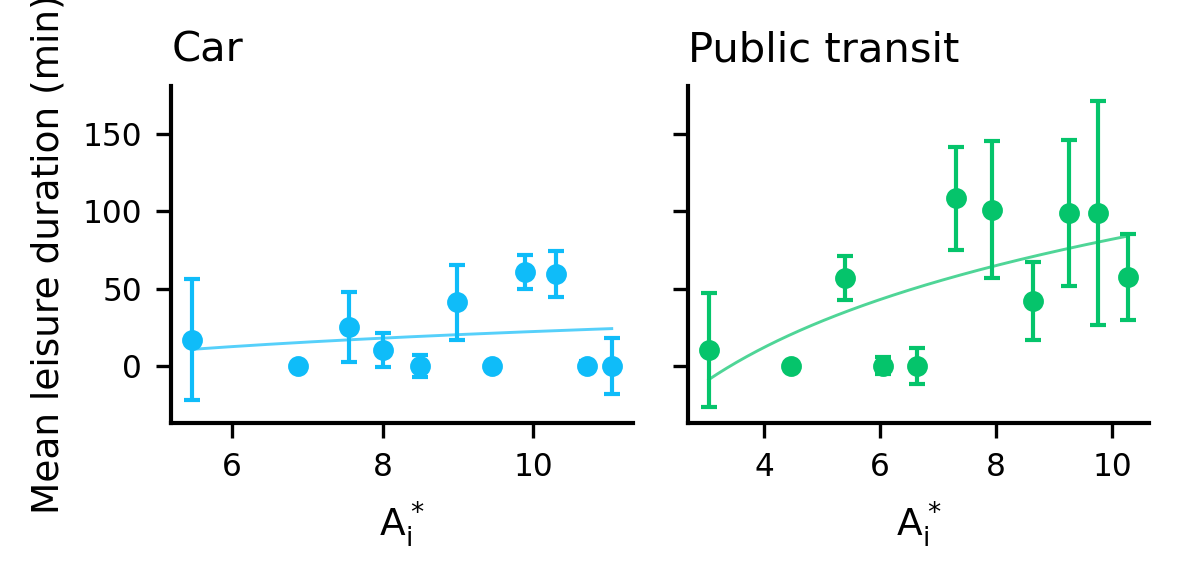

In [66]:
# Figure: STA vs total_travel_time
fig, _ = access_impact_plot(df_ak_g, y='mean_leisure_duration', ylb='Mean leisure duration (min)')
fig.savefig('figures/mean_leisure_duration.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Add Income and Save Output

In [22]:
# Get home coordinates
df_work = pd.read_csv('dbs/data_p/commuter_trips.csv')
df_work = df_work[df_work['purpose_d'] == 'HOME'].drop_duplicates(subset=['ID'])
df_work = df_work[['ID', 'end_lon', 'end_lat']].rename(columns={'end_lon': 'lon', 'end_lat': 'lat'})

# Create GeoDataFrame and spatial join with IRIS
df_work['geometry'] = df_work.apply(lambda row: Point(row['lon'], row['lat']), axis=1)
gdf_work = gpd.GeoDataFrame(df_work, geometry='geometry', crs='EPSG:4326')

gdf_iris = gpd.read_file('dbs/geo/paris_iris.geojson')
gdf_work = gpd.sjoin(gdf_work, gdf_iris[['code_iris', 'geometry']], how='left')

# Merge income data
df_income = pd.read_csv('dbs/data_p/income_2021_IRIS.csv')
gdf_work = gdf_work.merge(df_income, left_on='code_iris', right_on='IRIS', how='left')

print(f"Matched {gdf_work['poverty_rate'].notna().sum()} / {len(gdf_work)} with income data")

Matched 2040 / 2453 with income data


In [23]:
# Merge poverty rate to filtered data
df_filtered = df_filtered.merge(gdf_work[['ID', 'poverty_rate']], on='ID', how='left')

# Fill missing with weighted mean
mask = df_filtered['poverty_rate'].notna()
weighted_mean = np.average(df_filtered.loc[mask, 'poverty_rate'], weights=df_filtered.loc[mask, 'weight_ind'])
df_filtered['poverty_rate'] = df_filtered['poverty_rate'].fillna(weighted_mean)

print(f"Poverty rate: mean={df_filtered['poverty_rate'].mean():.2f}")

Poverty rate: mean=15.08


In [27]:
# Handle zero values for hill_q1 and mean_leisure_duration by filling with zero (or could consider separate category)
df_filtered.fillna(0, inplace=True)

In [28]:
# Save for R SEM model
df_filtered.to_csv('dbs/data_p/commuter_model_features_r.csv', index=False)
print('Saved: dbs/data_p/commuter_model_features_r.csv')

Saved: dbs/data_p/commuter_model_features_r.csv


In [ ]:
# Summary statistics
print('=== Sample Summary ===')
print(f"N = {len(df_filtered)}")
print(f"\nBy mode:")
print(df_filtered['mode'].value_counts())
print(f"\nSTA distribution (baseline budget=90):")
print(df_filtered['ak_cat'].value_counts())

print(f"\nSTA by budget level (mean ak_ihs):")
for b in [60, 75, 90, 120]:
    col = f'ak_{b}_ihs'
    nonzero_pct = (df_filtered[f'ak_{b}'] > 0).mean() * 100
    print(f"  Budget {b}: mean_ihs={df_filtered[col].mean():.2f}, pct_nonzero={nonzero_pct:.1f}%")

print(f"\nKey variables:")
for col in ['hill_q1', 'mean_leisure_duration', 'total_travel_time', 'ak', 'ak_ihs']:
    if col in df_filtered.columns:
        print(f"  {col}: mean={df_filtered[col].mean():.2f}, std={df_filtered[col].std():.2f}")